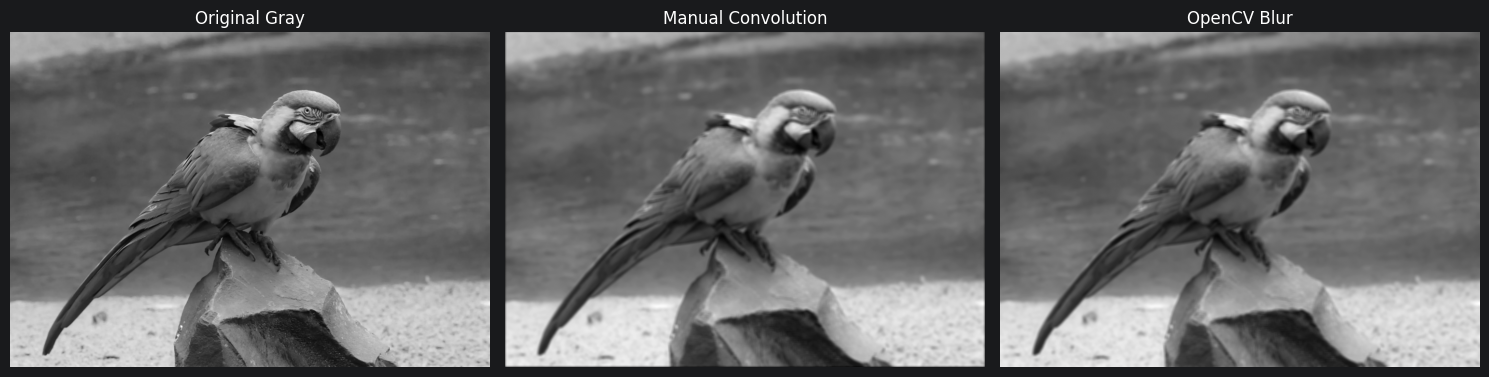

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. ĐỌC ẢNH
img_path = os.path.join('.', 'img_data', 'anhchim2.png')
img = cv2.imread(img_path)

if img is None:
    print("Không tìm thấy ảnh tại:", img_path)
    exit()

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

k_size = 7
kernel = np.ones((k_size, k_size), dtype=np.float32) / (k_size * k_size)

# CÁCH 1: DÙNG HÀM TỰ VIẾT (Manual Convolution)

def manual_convolution(image, kernel):
    h, w = image.shape
    k = kernel.shape[0]
    pad = k // 2


    output = np.zeros((h, w), dtype=np.float32)
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='constant')

    # Thực hiện trượt cửa sổ
    for y in range(h):
        for x in range(w):
            region = padded[y:y+k, x:x+k]
            value = np.sum(region * kernel)
            output[y, x] = value

    return np.clip(output, 0, 255).astype(np.uint8)

result_manual = manual_convolution(img_gray, kernel)


# CÁCH 2: DÙNG THƯ VIỆN OPENCV

# Theo tài liệu OpenCV, có 2 cách phổ biến để làm mờ
# Cách A: Dùng hàm blur chuyên dụng
result_opencv = cv2.blur(img_gray, (k_size, k_size))

# Cách B: Dùng filter2D (tổng quát hơn) làm mờ, làm nét, tìm cạnh, trích xuất đặc trưng
# result_opencv = cv2.filter2D(img_gray, -1, kernel)


# HIỂN THỊ
titles = ['Original Gray', 'Manual Convolution', 'OpenCV Blur']
images = [img_gray, result_manual, result_opencv]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()